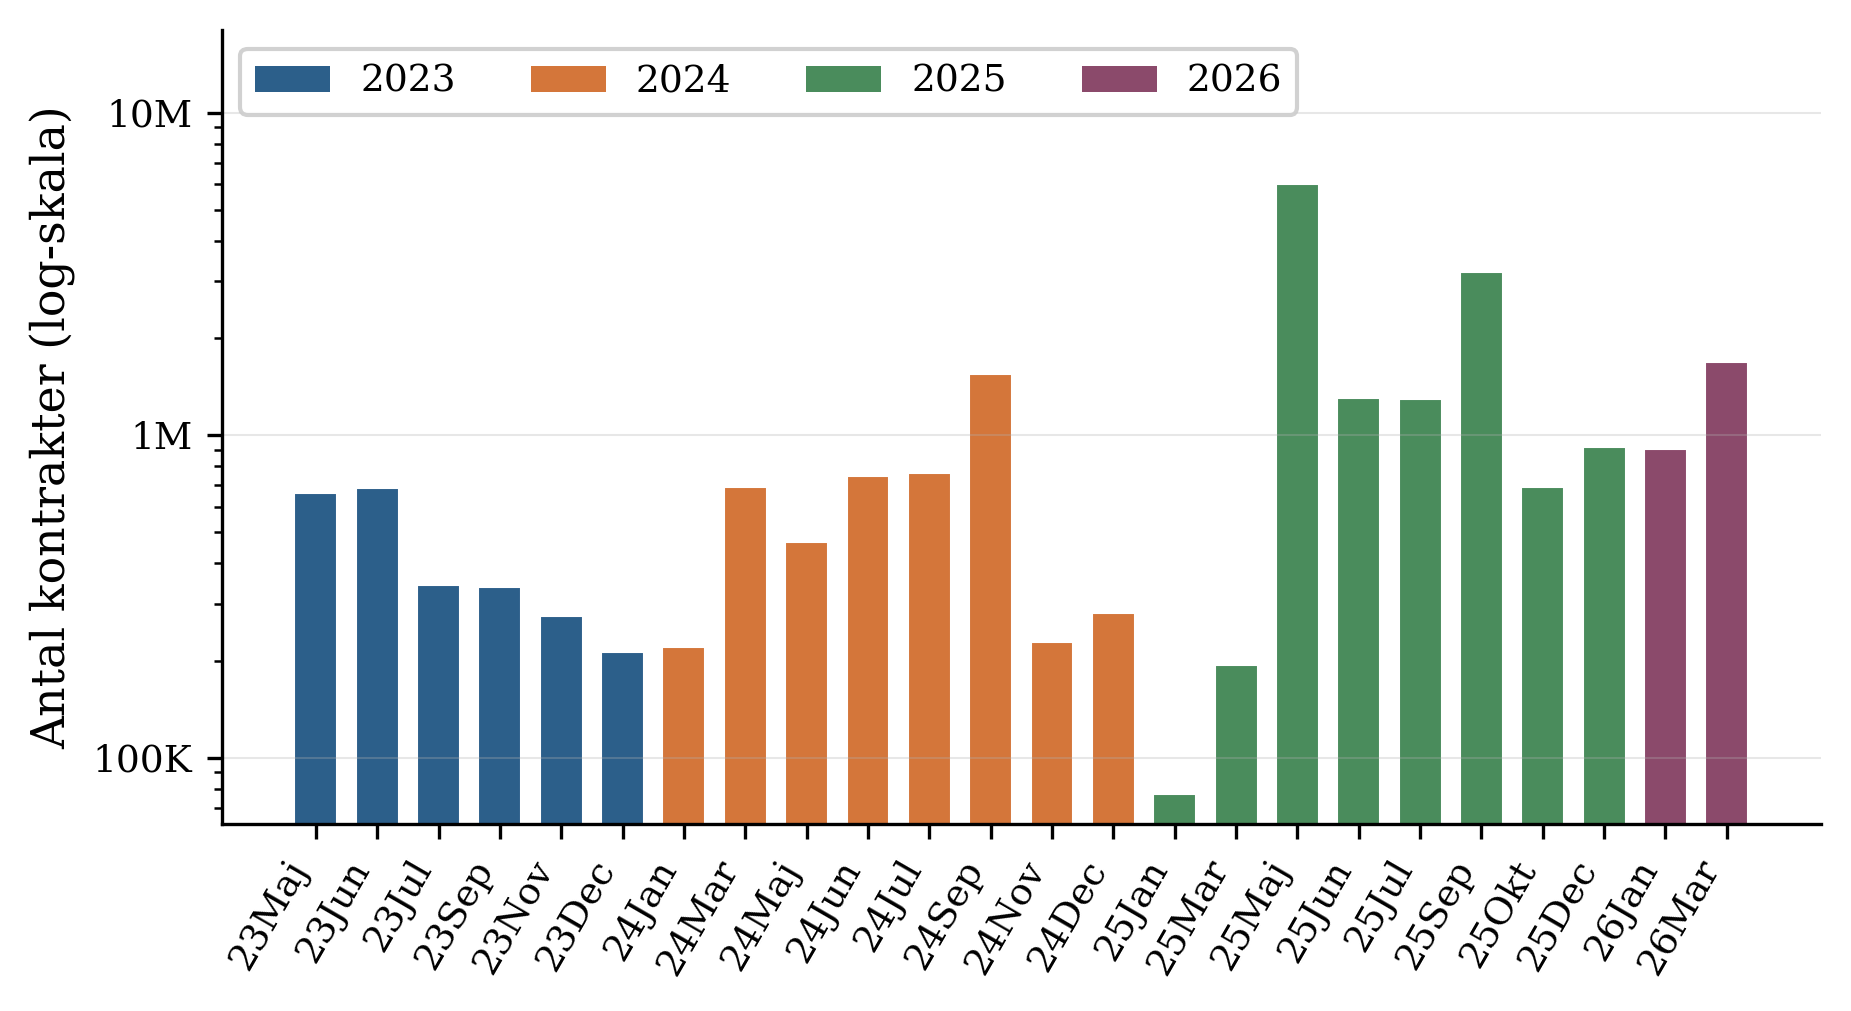

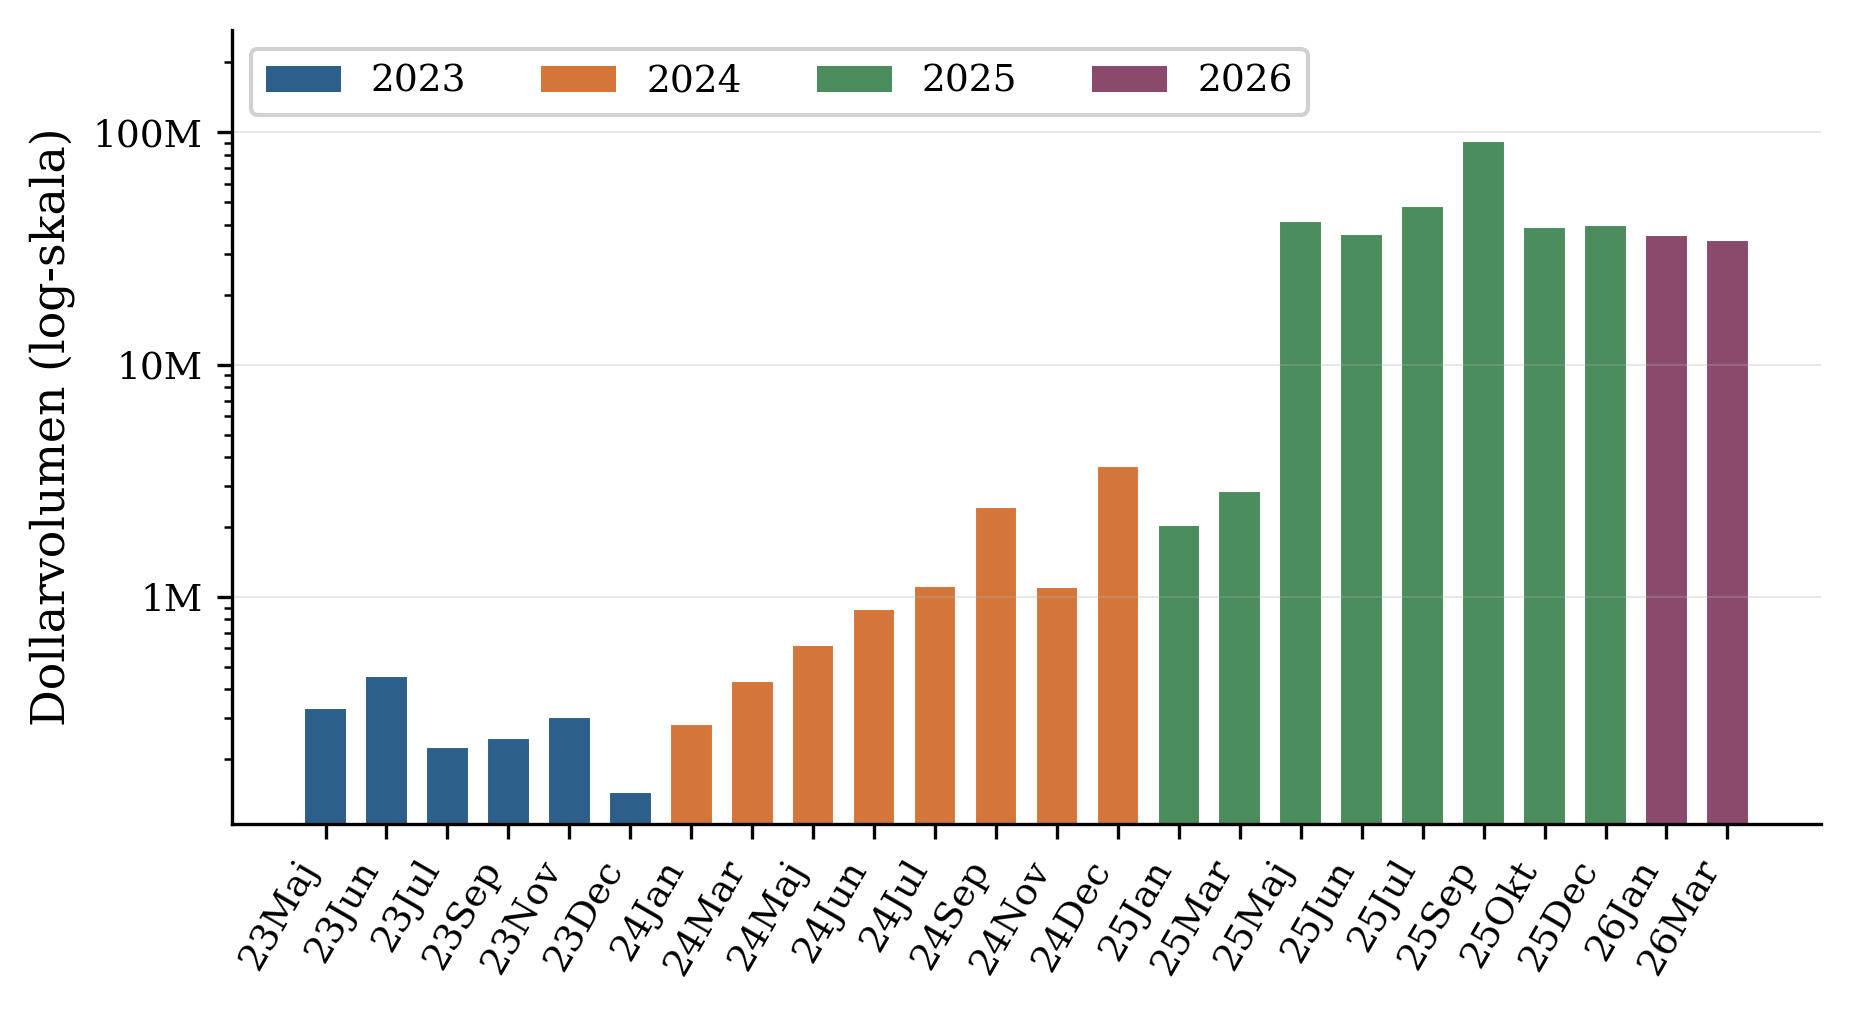

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.patches import Patch

# =============================================================================
# GLOBAL FIGUR-STIL — matcher LaTeX (11pt, Computer Modern, a4paper)
# =============================================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'CMU Serif', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.alpha': 0.3,
    'grid.linewidth': 0.5,
})

# Tekstbredde i LaTeX: 21cm - 2*2.5cm = 16cm ≈ 6.3 inches
TEXTWIDTH = 6.3

# =============================================================================
# DATA
# =============================================================================
meetings = [
    "FED-23MAY","FED-23JUN","FED-23JUL","FED-23SEP","FED-23NOV","FED-23DEC",
    "FED-24JAN","FED-24MAR","FED-24MAY","FED-24JUN","FED-24JUL","FED-24SEP",
    "FED-24NOV","FED-24DEC","FED-25JAN","FED-25MAR","FED-25MAY","FED-25JUN",
    "FED-25JUL","FED-25SEP","FED-25OCT","FED-25DEC","KXFED-26JAN","KXFED-26MAR"
]

kontrakt_vol = [
    660305,683354,342945,338975,274415,212389,220274,689580,466723,747081,
    762577,1550336,227610,281043,77197,193079,6015784,1307769,1291428,
    3212252,690529,919566,903789,1688449
]

dollar_vol = [
    332257,455278,225688,246231,304136,144860,283044,435669,619198,889026,
    1111574,2447178,1104684,3643679,2033985,2849985,41343139,36504721,
    48053671,91819656,39093798,39982396,35976526,34397322
]

# Danske månedsforkortelser: "23Maj", "24Jan", "26Mar" osv.
month_map = {
    'JAN': 'Jan', 'MAR': 'Mar', 'MAY': 'Maj', 'JUN': 'Jun',
    'JUL': 'Jul', 'SEP': 'Sep', 'OCT': 'Okt', 'NOV': 'Nov', 'DEC': 'Dec'
}
short_labels = []
for m in meetings:
    clean = m.replace("KXFED-", "").replace("FED-", "")
    year = clean[:2]
    month_code = clean[2:]
    short_labels.append(year + month_map[month_code])

# Farver per år (stil B)
year_colors = {2023: '#2c5f8a', 2024: '#d4763a', 2025: '#4a8c5c', 2026: '#8b4a6b'}
bar_colors = []
for m in meetings:
    if '23' in m:   bar_colors.append(year_colors[2023])
    elif '24' in m: bar_colors.append(year_colors[2024])
    elif '25' in m: bar_colors.append(year_colors[2025])
    else:           bar_colors.append(year_colors[2026])

def format_vol(x, pos):
    if x >= 1e6:   return f'{x/1e6:.0f}M'
    elif x >= 1e3: return f'{x/1e3:.0f}K'
    else:          return f'{x:.0f}'

legend_elements = [Patch(facecolor=c, label=str(y)) for y, c in year_colors.items()]

# =============================================================================
# FIGUR 1: Kontraktvolumen
# =============================================================================
fig, ax = plt.subplots(figsize=(TEXTWIDTH, 3.5))

ax.bar(range(len(meetings)), kontrakt_vol, color=bar_colors, edgecolor='white', linewidth=0.5, width=0.7)
ax.set_yscale('log')
ax.set_ylabel('Antal kontrakter (log-skala)')
ax.set_xticks(range(len(meetings)))
ax.set_xticklabels(short_labels, rotation=60, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_vol))
ax.set_ylim(top=max(kontrakt_vol) * 3)  # Plads øverst
ax.legend(handles=legend_elements, loc='upper left', framealpha=0.9, ncol=4)

plt.tight_layout()
# plt.savefig('fig_kontraktvolumen.png')
plt.show()

# =============================================================================
# FIGUR 2: Dollarvolumen
# =============================================================================
fig, ax = plt.subplots(figsize=(TEXTWIDTH, 3.5))

ax.bar(range(len(meetings)), dollar_vol, color=bar_colors, edgecolor='white', linewidth=0.5, width=0.7)
ax.set_yscale('log')
ax.set_ylabel('Dollarvolumen (log-skala)')
ax.set_xticks(range(len(meetings)))
ax.set_xticklabels(short_labels, rotation=60, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_vol))
ax.set_ylim(top=max(dollar_vol) * 3)  # Plads øverst
ax.legend(handles=legend_elements, loc='upper left', framealpha=0.9, ncol=4)

plt.tight_layout()
# plt.savefig('fig_dollarvolumen.png')
plt.show()

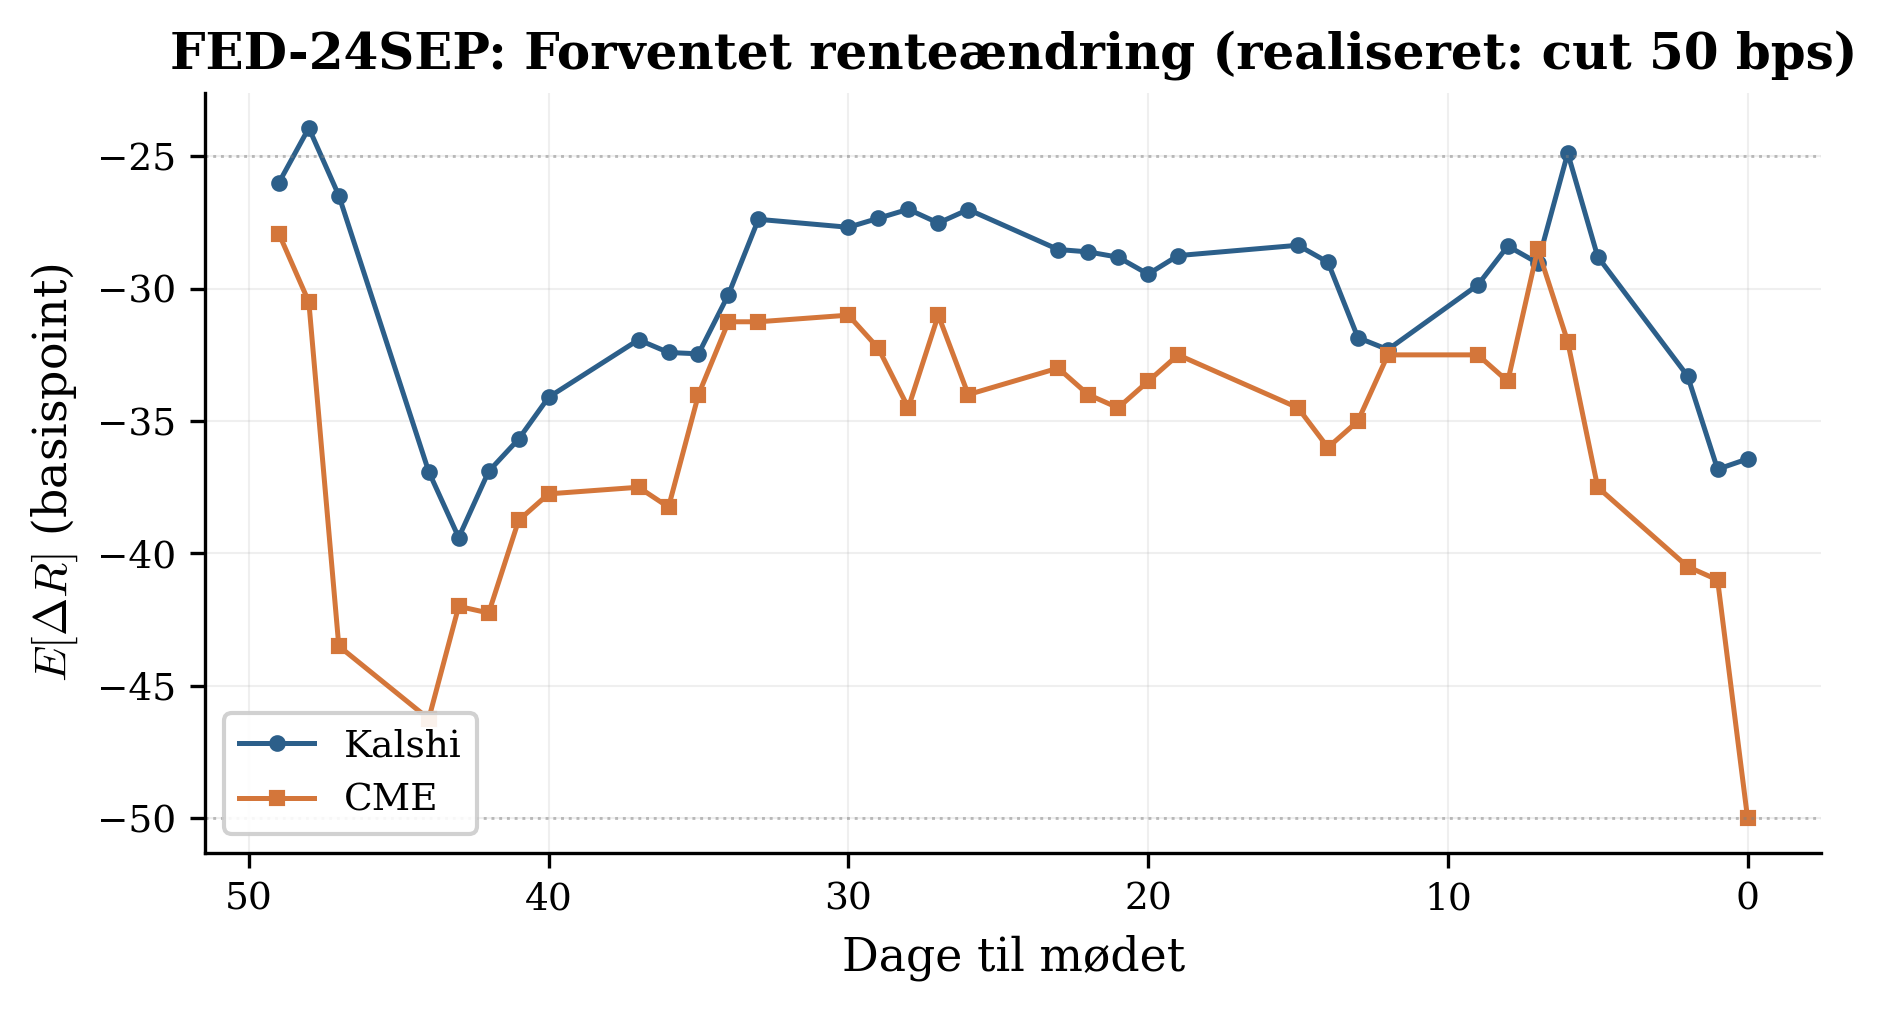

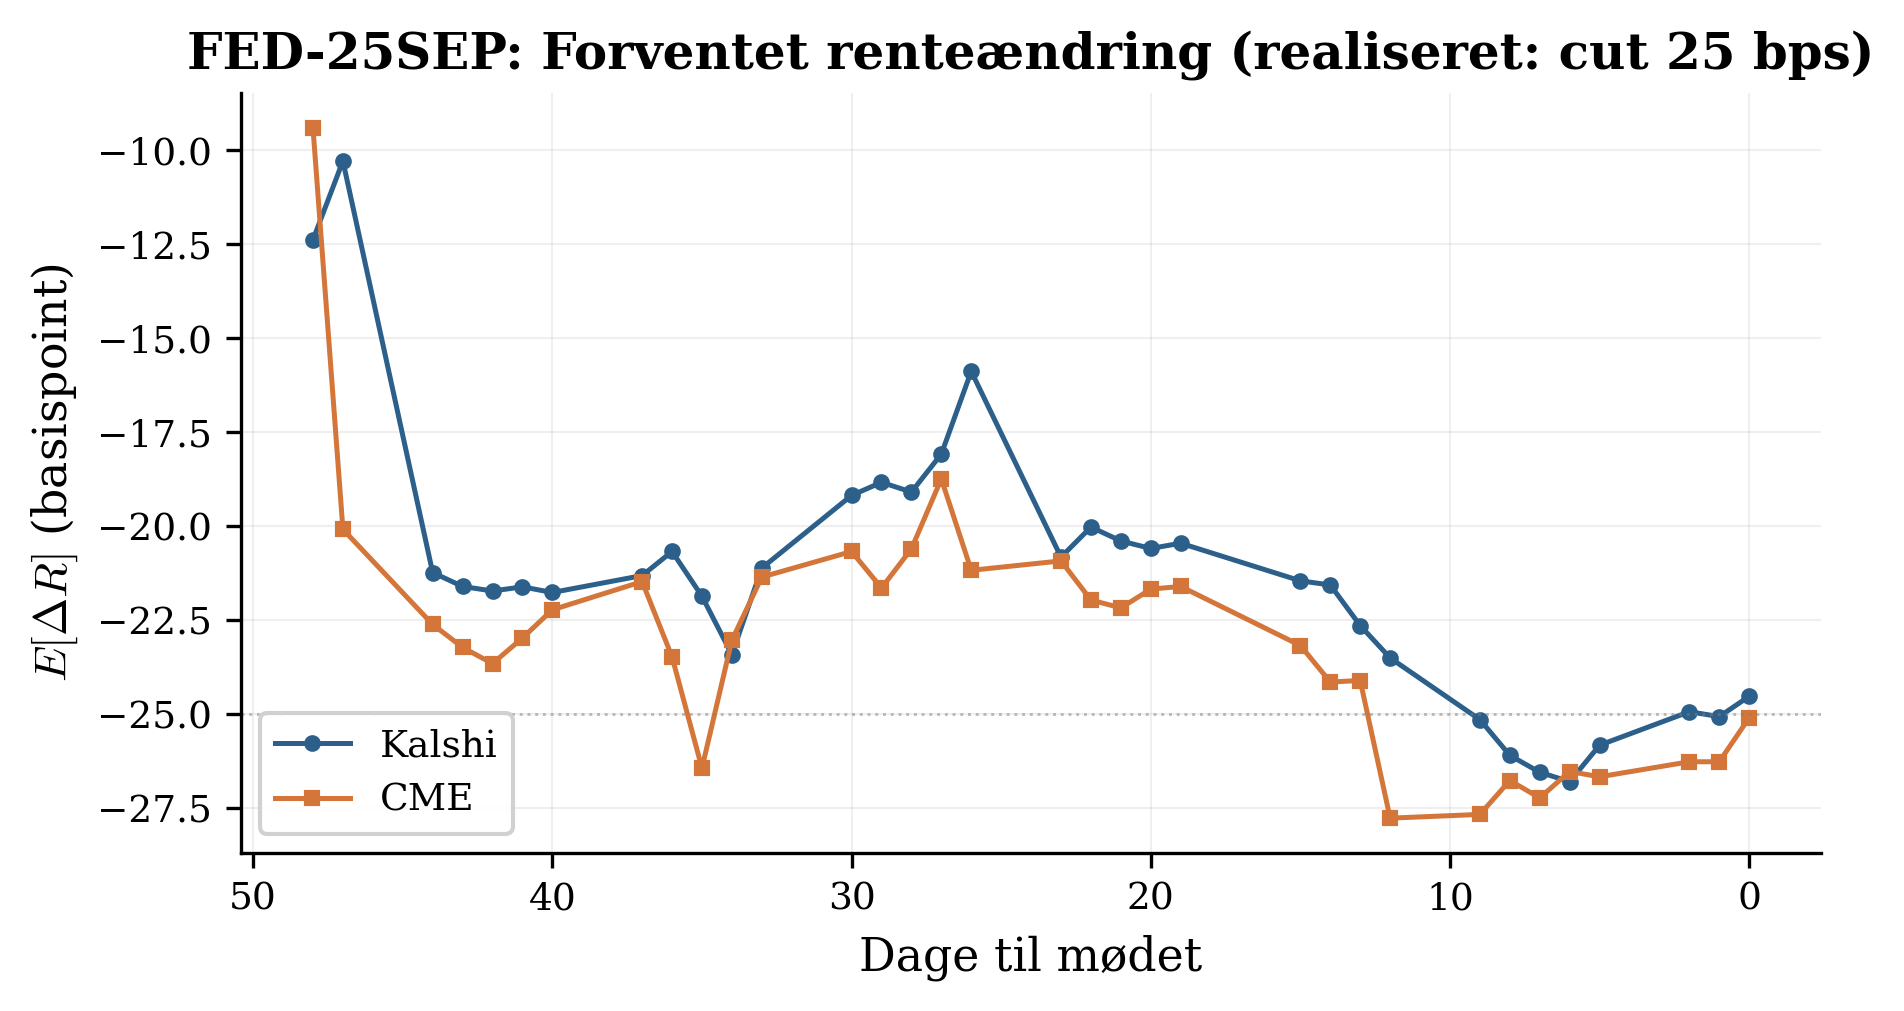

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import datetime

# =============================================================================
# GLOBAL FIGUR-STIL — matcher LaTeX (11pt, Computer Modern, a4paper)
# =============================================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'CMU Serif', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

TEXTWIDTH = 6.3
c_kalshi = '#2c5f8a'
c_cme = '#d4763a'

# =============================================================================
# DATA: FED-24SEP (verificeret mod 2026-Uge_13.xlsx)
# Realiseret: Cut 50 bps
# =============================================================================
dates_24 = [
    "2024-07-31","2024-08-01","2024-08-02","2024-08-05","2024-08-06",
    "2024-08-07","2024-08-08","2024-08-09","2024-08-12","2024-08-13",
    "2024-08-14","2024-08-15","2024-08-16","2024-08-19","2024-08-20",
    "2024-08-21","2024-08-22","2024-08-23","2024-08-26","2024-08-27",
    "2024-08-28","2024-08-29","2024-08-30","2024-09-03","2024-09-04",
    "2024-09-05","2024-09-06","2024-09-09","2024-09-10","2024-09-11",
    "2024-09-12","2024-09-13","2024-09-16","2024-09-17","2024-09-18"
]
kalshi_24 = [
    -26.00,-23.93,-26.48,-36.91,-39.40,-36.90,-35.68,-34.10,
    -31.93,-32.41,-32.46,-30.22,-27.38,-27.68,-27.34,-27.00,
    -27.52,-27.01,-28.52,-28.61,-28.81,-29.45,-28.75,-28.36,
    -29.00,-31.85,-32.30,-29.86,-28.39,-29.03,-24.88,-28.79,
    -33.30,-36.82,-36.43
]
cme_24 = [
    -27.92,-30.50,-43.50,-46.25,-42.00,-42.25,-38.75,-37.75,
    -37.50,-38.25,-34.00,-31.25,-31.25,-31.00,-32.25,-34.50,
    -31.00,-34.00,-33.00,-34.00,-34.50,-33.50,-32.50,-34.50,
    -36.00,-35.00,-32.50,-32.50,-33.50,-28.50,-32.00,-37.50,
    -40.50,-41.00,-50.00
]

# =============================================================================
# DATA: FED-25SEP (RETTET — CME E[ΔR] genberegnet fra CME FedWatch CSV)
# Realiseret: Cut 25 bps
# 9 datoer rettet: 13-aug, 5-17 sep (cut 50-sandsynlighed var ignoreret)
# =============================================================================
dates_25 = [
    "2025-07-31","2025-08-01","2025-08-04","2025-08-05","2025-08-06",
    "2025-08-07","2025-08-08","2025-08-11","2025-08-12","2025-08-13",
    "2025-08-14","2025-08-15","2025-08-18","2025-08-19","2025-08-20",
    "2025-08-21","2025-08-22","2025-08-25","2025-08-26","2025-08-27",
    "2025-08-28","2025-08-29","2025-09-02","2025-09-03","2025-09-04",
    "2025-09-05","2025-09-08","2025-09-09","2025-09-10","2025-09-11",
    "2025-09-12","2025-09-15","2025-09-16","2025-09-17"
]
kalshi_25 = [
    -12.38,-10.29,-21.23,-21.60,-21.72,-21.61,-21.76,-21.31,
    -20.67,-21.86,-23.41,-21.11,-19.18,-18.83,-19.09,-18.08,
    -15.88,-20.82,-20.02,-20.39,-20.59,-20.45,-21.45,-21.56,
    -22.64,-23.50,-25.14,-26.09,-26.54,-26.79,-25.82,-24.93,
    -25.06,-24.52
]
cme_25 = [
    -9.41,-20.08,-22.61,-23.22,-23.65,-22.97,-22.22,-21.47,
    -23.47,-26.43,  # <-- 13-aug rettet fra -25.00
    -23.03,-21.35,-20.67,-21.64,-20.60,-18.74,
    -21.17,-20.92,-21.96,-22.17,-21.67,-21.60,-23.17,-24.14,
    -24.10,
    -27.76,  # <-- 05-sep rettet fra -25.00
    -27.66,  # <-- 08-sep rettet fra -25.00
    -26.76,  # <-- 09-sep rettet fra -25.00
    -27.22,  # <-- 10-sep rettet fra -25.00
    -26.52,  # <-- 11-sep rettet fra -25.00
    -26.66,  # <-- 12-sep rettet fra -25.00
    -26.26,  # <-- 15-sep rettet fra -25.00
    -26.26,  # <-- 16-sep rettet fra -25.00
    -25.09   # <-- 17-sep rettet fra -25.00
]

# Dage til mødet
meeting_24 = datetime.datetime(2024, 9, 18)
meeting_25 = datetime.datetime(2025, 9, 17)
t_minus_24 = [(meeting_24 - datetime.datetime.strptime(d, "%Y-%m-%d")).days for d in dates_24]
t_minus_25 = [(meeting_25 - datetime.datetime.strptime(d, "%Y-%m-%d")).days for d in dates_25]

# =============================================================================
# FIGUR: FED-24SEP — Høj usikkerhed (25 vs. 50 bps cut)
# =============================================================================
fig, ax = plt.subplots(figsize=(TEXTWIDTH, 3.5))

ax.plot(t_minus_24, kalshi_24, '-o', color=c_kalshi, markersize=3, linewidth=1.2, label='Kalshi')
ax.plot(t_minus_24, cme_24, '-s', color=c_cme, markersize=3, linewidth=1.2, label='CME')
ax.set_title('FED-24SEP: Forventet renteændring (realiseret: cut 50 bps)', fontweight='bold')
ax.set_xlabel('Dage til mødet')
ax.set_ylabel(r'$E[\Delta R]$ (basispoint)')
ax.invert_xaxis()
ax.axhline(y=-25, color='grey', linestyle=':', linewidth=0.7, alpha=0.5)
ax.axhline(y=-50, color='grey', linestyle=':', linewidth=0.7, alpha=0.5)
ax.grid(axis='both', alpha=0.2, linewidth=0.5)
ax.legend(loc='lower left', framealpha=0.9)

plt.tight_layout()
# plt.savefig('fig_fed24sep.png')
plt.show()

# =============================================================================
# FIGUR: FED-25SEP — Rettet CME-data, Kalshi modnet
# =============================================================================
fig, ax = plt.subplots(figsize=(TEXTWIDTH, 3.5))

ax.plot(t_minus_25, kalshi_25, '-o', color=c_kalshi, markersize=3, linewidth=1.2, label='Kalshi')
ax.plot(t_minus_25, cme_25, '-s', color=c_cme, markersize=3, linewidth=1.2, label='CME')
ax.set_title('FED-25SEP: Forventet renteændring (realiseret: cut 25 bps)', fontweight='bold')
ax.set_xlabel('Dage til mødet')
ax.set_ylabel(r'$E[\Delta R]$ (basispoint)')
ax.invert_xaxis()
ax.axhline(y=-25, color='grey', linestyle=':', linewidth=0.7, alpha=0.5)
ax.grid(axis='both', alpha=0.2, linewidth=0.5)
ax.legend(loc='lower left', framealpha=0.9)

plt.tight_layout()
# plt.savefig('fig_fed25sep.png')
plt.show()